In [301]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [302]:
data = pd.read_csv("../data/raw/HealthConnect_Appointment_Data.csv")
print(data.shape)
print(f" That is {data.shape[0]} Rows and {data.shape[1]} Columns")
data.head(20)

(5000, 18)
 That is 5000 Rows and 18 Columns


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show
5,HC-00006,P-0523,Male,66,65+,Specialist Consultation,2/16/2026,4/14/2026,Tuesday,Morning,57,4,2,No,NaN,3.1,36.0,No-Show
6,HC-00007,P-0776,Male,58,55-64,Diagnostic Test,1/17/2025,2/16/2025,Sunday,Afternoon,30,4,1,Yes,WhatsApp,8.2,30.0,No-Show
7,HC-00008,P-0927,Female,28,25-34,Specialist Consultation,11/27/2025,1/16/2026,Friday,Afternoon,50,6,1,Yes,SMS,19.2,21.0,Attended
8,HC-00009,P-0388,Male,77,65+,Follow-up,3/9/2025,4/21/2025,Monday,Afternoon,43,3,0,Yes,SMS,10.1,27.0,No-Show
9,HC-00010,P-0371,Female,20,18-24,Follow-up,2/5/2025,2/21/2025,Friday,Afternoon,16,2,0,Yes,SMS,28.0,20.0,Attended


## handling data type

In [303]:
## We constat our target is categorical type , we have to turn it in numerical
data["appointment_outcome"] = data["appointment_outcome"].map({"No-Show":0, "Attended":1 , "Cancelled":2})
data.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,0
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,1
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,0
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,1
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,0


In [304]:
## Another point is this booking_date	appointment_date two feature that pandas intepret like object , so we have to say to pandas no it's not object but date
data['booking_date'] = pd.to_datetime(data['booking_date'])
data['appointment_date'] =pd.to_datetime(data['appointment_date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   appointment_id         5000 non-null   object        
 1   patient_id             5000 non-null   object        
 2   gender                 5000 non-null   object        
 3   age                    5000 non-null   int64         
 4   age_group              5000 non-null   object        
 5   appointment_type       5000 non-null   object        
 6   booking_date           5000 non-null   datetime64[ns]
 7   appointment_date       5000 non-null   datetime64[ns]
 8   appointment_day        5000 non-null   object        
 9   appointment_time       5000 non-null   object        
 10  booking_lead_days      5000 non-null   int64         
 11  previous_appointments  5000 non-null   int64         
 12  previous_no_shows      5000 non-null   int64         
 13  rem

In [305]:
## HANDLING OUTLIERS 


In [306]:
#exploratory Analysis show many outliers in 02 or 03 features  

In [307]:
num_features = ['age',
 'booking_lead_days',
 'previous_appointments',
 'distance_to_clinic_km',
 'waiting_time_minutes']

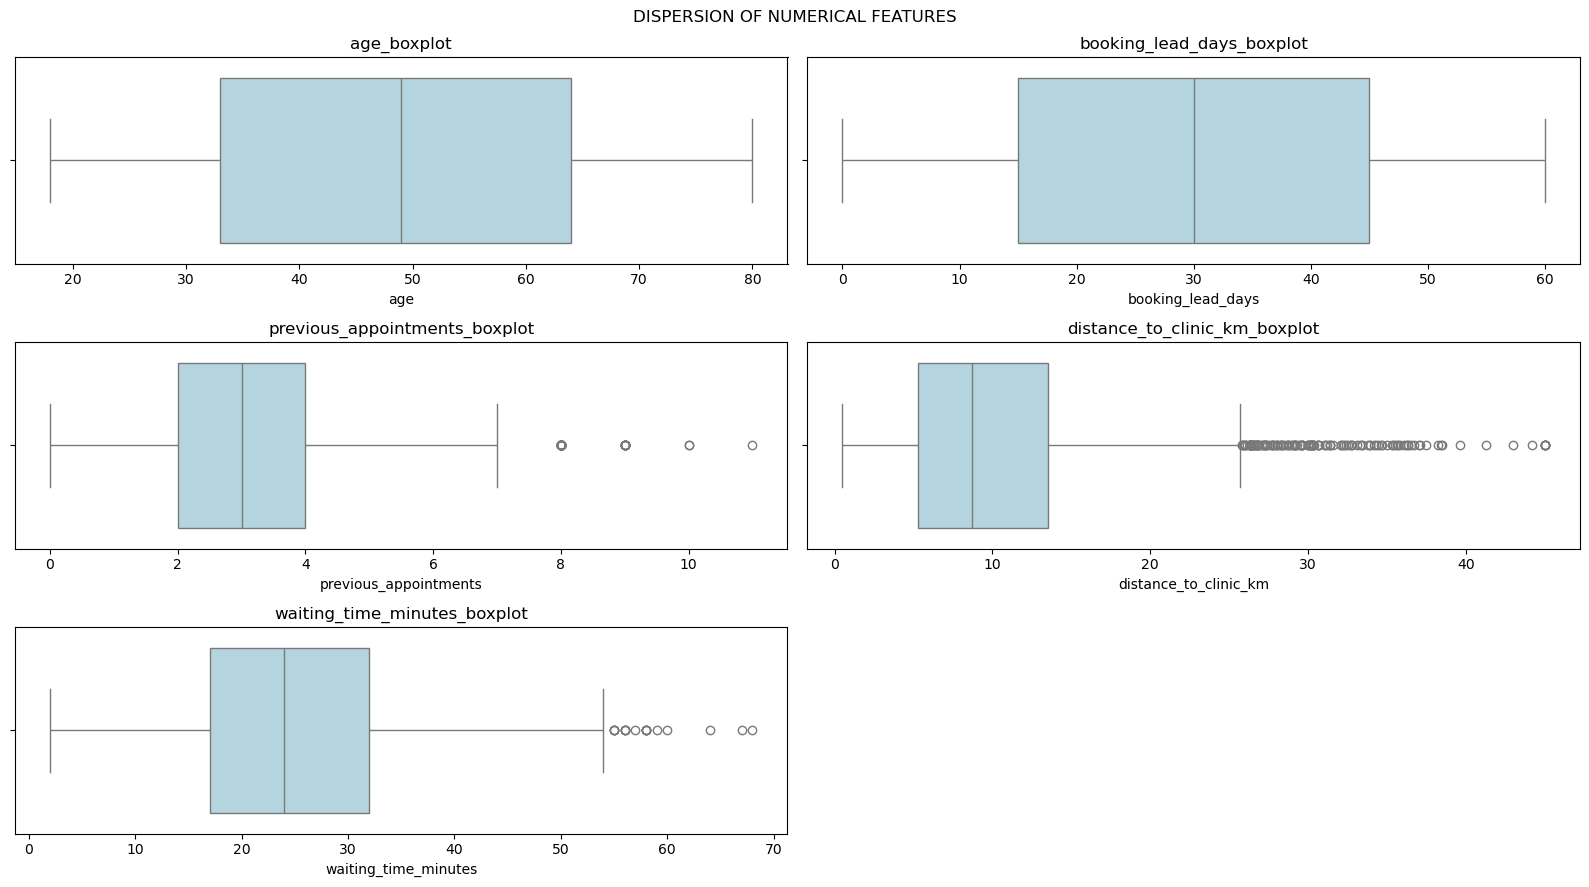

In [308]:
fig ,ax = plt.subplots(3,2, figsize=(16,9))
ax = ax.flatten()
for index, val in enumerate(num_features):
 sns.boxplot(data=data , x=val ,  color="lightblue", ax=ax[index] )
 ax[index].set(title=f"{val}_boxplot" )
for i in range( len(num_features) , len(ax)):
    fig.delaxes(ax[i])
plt.suptitle("DISPERSION OF NUMERICAL FEATURES")
plt.tight_layout()
plt.savefig("../image/UNIVARIATE/boxplot_univariate.png")
plt.show()

In [309]:
## In that case , it w'ont be right to remove that points that is far from data concentration because , that point might be right and we don't have many information 
## information to say for example a distance_to_clinic of 30 is anormal cause that case is totaly normal , same for previous_appointements
## so to conclude we prefer let that point like that

## FEATURE ENGINEERING

In [310]:
## in this part , we are going to create meaningful new features

In [311]:

bins = [0, 7, 30, 90, float('inf')]
labels = ['Last minute (0-7d)', 'Short term (8-30d)', 'Medium term (31-90d)', 'Long term (90d+)']
data["lead_cat_temp"] = pd.cut(data['booking_lead_days'], bins=bins, labels=labels, include_lowest=True)
## lead_cat_temp bring more details about target and Booking_lead_days , more your booking_lead_days is long more patient have hight chance to miss appointement

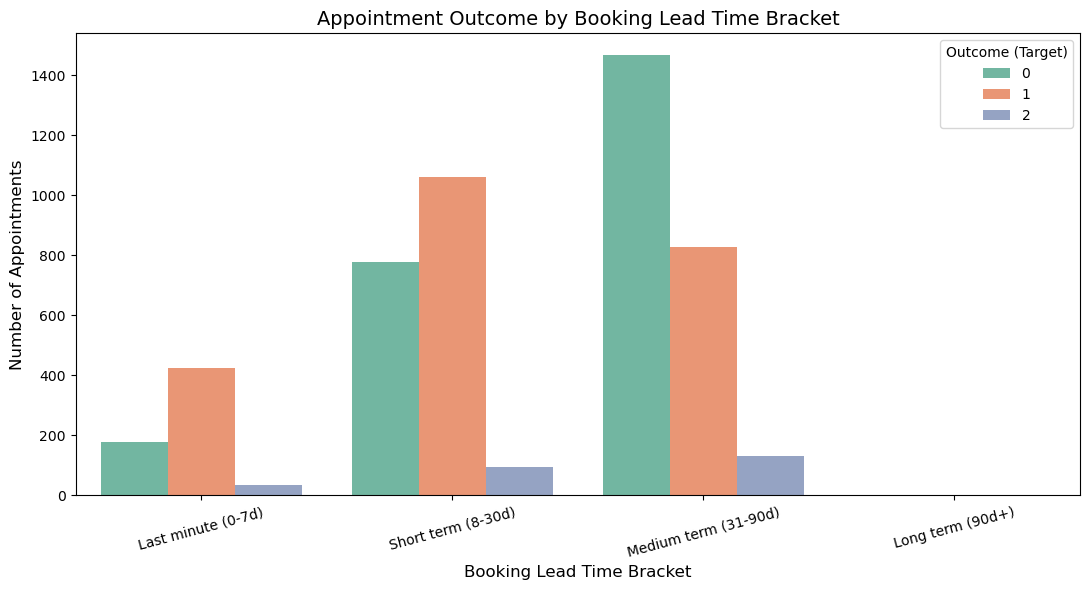

In [312]:
# 2. Plot the countplot passing this temporary series to the x axis
plt.figure(figsize=(11, 6))
sns.countplot(
    data=data,
    x="lead_cat_temp",
    hue="appointment_outcome",
    palette='Set2'
)

plt.title("Appointment Outcome by Booking Lead Time Bracket", fontsize=14)
plt.xlabel("Booking Lead Time Bracket", fontsize=12)
plt.ylabel("Number of Appointments", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Outcome (Target)")
plt.savefig("../image/BIVARIATE/booking_lead_time_X_appointment_outcome.png")  
plt.tight_layout()
plt.show()

In [313]:
## with appointment and booking day we might extract more information like , the month and the week days of appointment 
data["booking_month"] = data["booking_date"].dt.month_name()
data["appointment_month"] =  data["appointment_date"].dt.month_name()
data["booking_day"] = data["booking_date"].dt.day_name()
data["appointment_day"] =  data["appointment_date"].dt.day_name()
data.head()


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,lead_cat_temp,booking_month,appointment_month,booking_day
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,...,0,Yes,WhatsApp,19.3,29.0,0,Short term (8-30d),February,February,Thursday
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,...,0,Yes,SMS,14.3,42.0,1,Last minute (0-7d),February,February,Wednesday
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,...,1,Yes,SMS,11.4,11.0,0,Medium term (31-90d),November,December,Sunday
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,...,1,Yes,SMS,7.4,35.0,1,Medium term (31-90d),July,August,Friday
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,...,1,Yes,Email,5.6,27.0,0,Medium term (31-90d),July,August,Wednesday


Based on our EDA and business logic, our goal is to detect patients who don't show up for appointments. We currently have three classes: No-shows, Attended, and Cancelled. Since Cancelled has a very low proportion, keeping it separate might introduce noise during training. I propose merging Cancelled into the No-shows category, as they are conceptually and behaviorally closer.

In [314]:
## We constat our target is categorical type , we have to turn it in numerical
data["appointment_outcome"] = data["appointment_outcome"].replace(2,0)
print(data["appointment_outcome"].nunique())
data.head()

2


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,lead_cat_temp,booking_month,appointment_month,booking_day
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,...,0,Yes,WhatsApp,19.3,29.0,0,Short term (8-30d),February,February,Thursday
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,...,0,Yes,SMS,14.3,42.0,1,Last minute (0-7d),February,February,Wednesday
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,...,1,Yes,SMS,11.4,11.0,0,Medium term (31-90d),November,December,Sunday
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,...,1,Yes,SMS,7.4,35.0,1,Medium term (31-90d),July,August,Friday
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,...,1,Yes,Email,5.6,27.0,0,Medium term (31-90d),July,August,Wednesday


In [315]:
## DELETE INEFFICIENT Features

In [316]:
data.drop(labels=['appointment_id', 'patient_id'] , axis=1 , inplace=True)
data.head()


,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,lead_cat_temp,booking_month,appointment_month,booking_day
0,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,0,Short term (8-30d),February,February,Thursday
1,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,1,Last minute (0-7d),February,February,Wednesday
2,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,0,Medium term (31-90d),November,December,Sunday
3,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,1,Medium term (31-90d),July,August,Friday
4,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,0,Medium term (31-90d),July,August,Wednesday


In [317]:
# 1. TRI CHRONOLOGIQUE STRICT sur la date de rendez-vous
data = data.sort_values('appointment_date').reset_index(drop=True)

# 2. Séparation Features (X) et Target (Y)
X = data.drop(columns=['appointment_outcome'])
Y = data['appointment_outcome']

# 3. DIVISION TEMPORELLE (80% Train / 20% Test)
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

Y_train = Y.iloc[:split_index]
Y_test = Y.iloc[split_index:]

print(f"Période Train : du {X_train['appointment_date'].min()} au {X_train['appointment_date'].max()}")
print(f"Période Test  : du {X_test['appointment_date'].min()} au {X_test['appointment_date'].max()}")

Période Train : du 2025-01-01 00:00:00 au 2026-03-13 00:00:00
Période Test  : du 2026-03-13 00:00:00 au 2026-06-30 00:00:00


## Handling Missing values & Normalisation & ENCODING OF CATEGORICAL FEATURES

In [318]:
## Instanciation of transformers

In [319]:
 Numeric = X_train.select_dtypes(include="number").columns.to_list()
Categorical = X_train.select_dtypes(["object", "category"]).columns.to_list()

In [320]:
Categorical

['gender',
 'age_group',
 'appointment_type',
 'appointment_day',
 'appointment_time',
 'reminder_sent',
 'reminder_channel',
 'lead_cat_temp',
 'booking_month',
 'appointment_month',
 'booking_day']

In [321]:
Numeric

['age',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'distance_to_clinic_km',
 'waiting_time_minutes']

In [322]:
Numeric.remove('previous_no_shows')

In [323]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

# 2. Pipeline pour les variables numériques (Imputation puis Standardisation)
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

# 3. Le ColumnTransformer final qui assemble le tout
transformer = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, Categorical),
        ('num', num_pipeline, Numeric)
    ],
    remainder='passthrough'
)

In [324]:

# 1. Avant de lancer le transformer, on supprime définitivement les colonnes de dates brutes 
colonnes_dates_a_supprimer = ['booking_date', 'appointment_date']

X_train = X_train.drop(columns=[col for col in colonnes_dates_a_supprimer if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in colonnes_dates_a_supprimer if col in X_test.columns])

# 2. Ajustement et transformation
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

# 3. Récupération propre des noms dans l'ordre réel du ColumnTransformer :
encoded_cat_cols = transformer.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(Categorical)
numeric_cols = Numeric

# CORRECTION ICI : Le remainder correspond à toutes les colonnes qui n'étaient NI dans Categorical NI dans Numeric
passthrough_cols = [col for col in X_train.columns if col not in Categorical and col not in Numeric]

# Assemblage dans le VRAI ordre de sortie du ColumnTransformer
all_columns = list(encoded_cat_cols) + list(numeric_cols) + list(passthrough_cols)

# 4. Recréation des DataFrames propres pour X
X_train_clean = pd.DataFrame(X_train_transformed, columns=all_columns)
X_test_clean = pd.DataFrame(X_test_transformed, columns=all_columns)

# S'assurer que y est géré proprement en 1D ou DataFrame standard pour l'export
y_train_df = pd.DataFrame(Y_train)
y_test_df = pd.DataFrame(Y_test)

# 5. Sauvegarde permanente des 4 fichiers distincts
X_train_clean.to_csv('../data/processed/X_train_processed.csv', index=False)
X_test_clean.to_csv('../data/processed/X_test_processed.csv', index=False)
y_train_df.to_csv('../data/processed/y_train_processed.csv', index=False)
y_test_df.to_csv('../data/processed/y_test_processed.csv', index=False)

print("Les 4 datasets ont été nettoyés, alignés et sauvegardés avec succès !")

Les 4 datasets ont été nettoyés, alignés et sauvegardés avec succès !


In [325]:
import joblib
# 1. Sauvegarder le ColumnTransformer
joblib.dump(transformer, '../models/column_transformer.pkl')

['../models/column_transformer.pkl']